<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/MachineV_Practical_04_CM23057.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [3]:
dataset_path = kagglehub.dataset_download("rdsunday/neu-urface-defect-database")

print("Dataset Path:")
print(dataset_path)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]

Extracting files...


Dataset Path:
/root/.cache/kagglehub/datasets/rdsunday/neu-urface-defect-database/versions/1


In [4]:
image_paths = glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True)

print("Total Images:", len(image_paths))

image_path = image_paths[0]

print("Selected Image:")
print(image_path)

Total Images: 1800
Selected Image:
/root/.cache/kagglehub/datasets/rdsunday/neu-urface-defect-database/versions/1/NEU-DET/IMAGES/patches_151.jpg


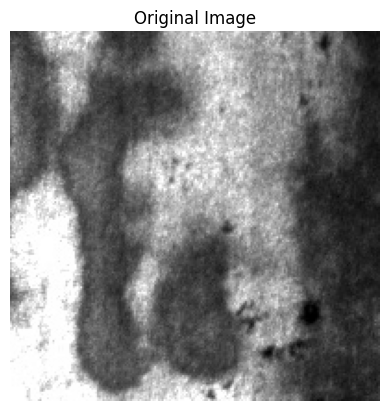

In [5]:
image = cv2.imread(image_path)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

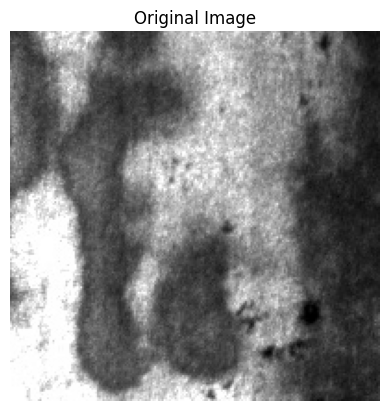

In [6]:
image = cv2.imread(image_path)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

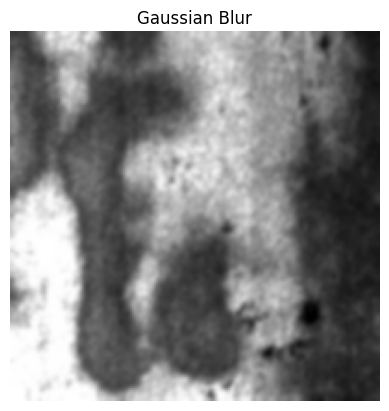

In [8]:
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

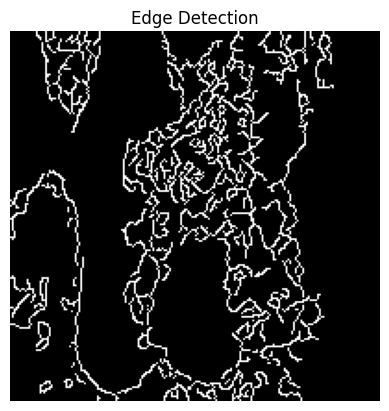

In [9]:
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()

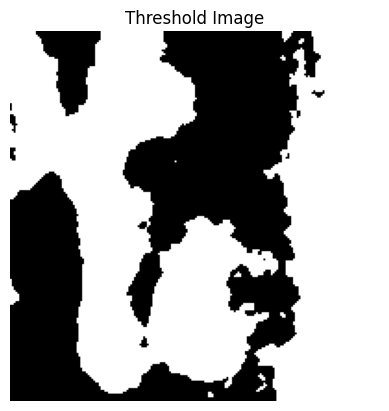

In [10]:
_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(threshold, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

In [11]:
kernel = np.ones((3,3), np.uint8)

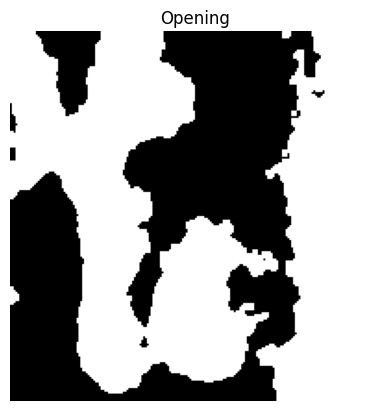

In [12]:
opening = cv2.morphologyEx(
    threshold,
    cv2.MORPH_OPEN,
    kernel
)

plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")
plt.show()

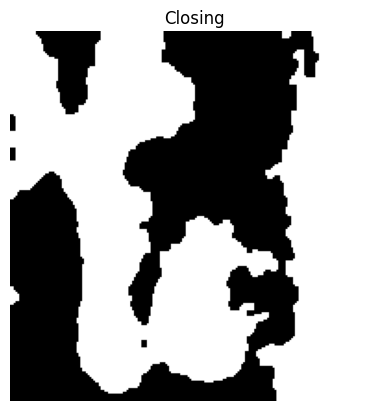

In [13]:
closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel
)

plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")
plt.show()

In [14]:
contours, hierarchy = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total Contours Detected:", len(contours))

Total Contours Detected: 4


Detected Defects: 2


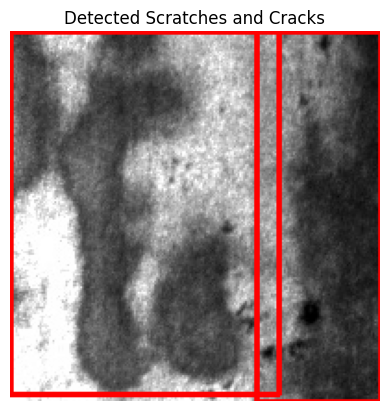

In [15]:
result = rgb.copy()

count = 0

for contour in contours:

    area = cv2.contourArea(contour)

    if area > 30:

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            result,
            (x, y),
            (x+w, y+h),
            (255,0,0),
            2
        )

        count += 1

print("Detected Defects:", count)

plt.imshow(result)
plt.title("Detected Scratches and Cracks")
plt.axis("off")
plt.show()

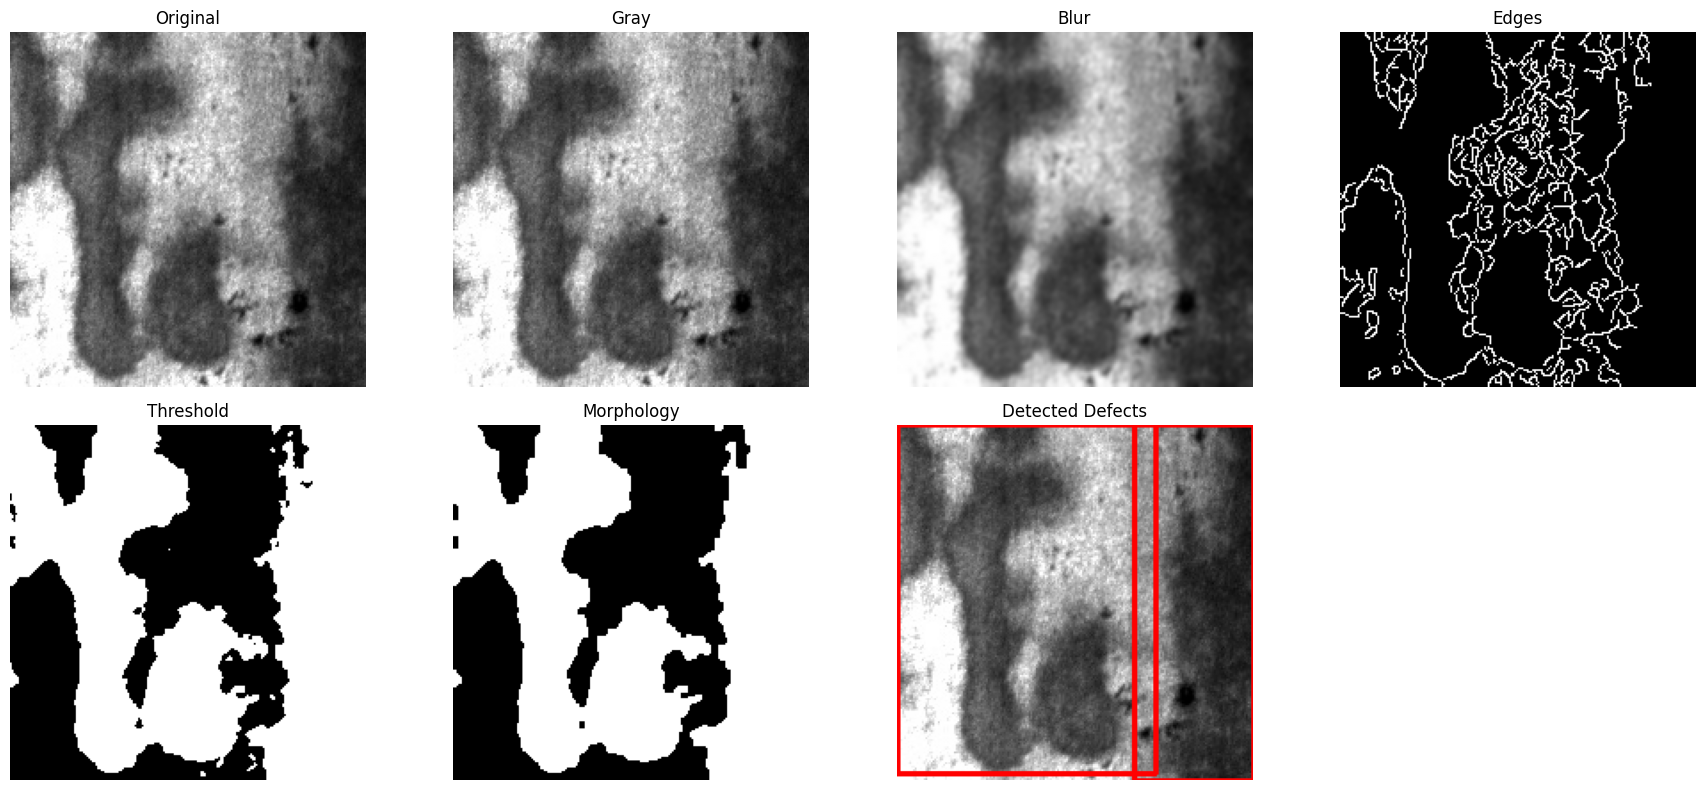

In [16]:
titles = [
    "Original",
    "Gray",
    "Blur",
    "Edges",
    "Threshold",
    "Morphology",
    "Detected Defects"
]

images = [
    rgb,
    gray,
    blur,
    edges,
    threshold,
    closing,
    result
]

plt.figure(figsize=(18,8))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape)==2:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()